In [1]:
import os
import time
import json
import pandas as pd
import pydicom as pdcm
from glob import glob
from tqdm import tqdm
from pydicom import dcmread

C:\Users\MacRaeDC\AppData\Local\Temp\ipykernel_31224\2705401398.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [34]:
df_all_features = pd.read_excel("datasets/MT_dataset/patients_all_features.xlsx")


df_all_features.to_csv("datasets/MT_dataset/patients_all_features.csv", index=False, sep=";")

In [163]:
CITOR_REDCAP_filepath = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/CITOR_REDCAP_clinical_data_important_variables_combined.xlsx"


df_CITOR_REDCAP = pd.read_excel(CITOR_REDCAP_filepath, sheet_name="CITOR_REDCAP_clinical_data_impo")



In [4]:
from data_preproc import data_preproc_config 

frame_of_ref_uid_tag = data_preproc_config.frame_of_ref_uid_tag
frame_of_ref_uid_tag

'00200052'

In [2]:
def get_metadata_rtdose(path_rtdose_file):
    # Load RTDOSE file
    ds = dcmread(path_rtdose_file)

    # Construct metadata_rtdose
    metadata_rtdose = json.loads(ds.to_json())

    return metadata_rtdose


def get_metadata_ct(path_ct):
    # Load CT slice
    slices_path = glob(path_ct + '/*')
    # slices_path = sort_human(slices_path)
    slice = pdcm.read_file(slices_path[0])

    # Construct metadata_ct
    metadata_ct = json.loads(slice.to_json())

    return metadata_ct


def get_metadata_rtstruct(path_rtstruct_file):
    # Load RTSTRUCT file
    ds = dcmread(path_rtstruct_file)

    # Construct metadata_rtdose
    metadata_rtstruct = json.loads(ds.to_json())

    return metadata_rtstruct

def get_reference_frame_ct(path_ct):
    metadata = get_metadata_ct(path_ct)
    frame_of_ref_uid = metadata[frame_of_ref_uid_tag]['Value'][0]

    return frame_of_ref_uid

def get_reference_frame_rtdose(path_rtdose_file):
    metadata = get_metadata_rtdose(path_rtdose_file)
    frame_of_ref_uid = metadata[frame_of_ref_uid_tag]['Value'][0]

    return frame_of_ref_uid
    
def get_reference_frame_rtstruct(path_rtstruct_file):
    metadata = get_metadata_rtstruct(path_rtstruct_file)
    frame_of_ref_uid = metadata['30060010']['Value'][0][frame_of_ref_uid_tag]['Value'][0]

    return frame_of_ref_uid

In [5]:
patient_ID_list = data_preproc_config.test_patients_list

patient_folder_types = data_preproc_config.patient_folder_types
data_dir_mode_list = data_preproc_config.save_dir_mode_list
data_dir = data_preproc_config.data_dir.format(data_dir_mode_list[0])

patient_ID_list = ["4673928"]

# Get all patient folders
for patient_id in tqdm(patient_ID_list):
    patient_folder = os.path.join(data_dir, patient_id)
    all_folders_i = os.listdir(patient_folder)

    for f_t in patient_folder_types:
        if f_t in all_folders_i:
            folder_type_i = f_t

            CT_path = os.path.join(patient_folder, f_t, "CT")
            #print(CT_path)

            # NOTE: DANIEL: add a check for the the UIDs here ! ! 
            break
        else:
            folder_type_i = None
    print(patient_id, folder_type_i)

100%|██████████| 1/1 [00:00<00:00, 126.02it/s]

4673928 with_contrast


In [308]:
folder_type_i

'with_contrast'

In [404]:
def check_if_CT_UID_matches_available_RTDOSE_and_RTSTRUCT_images(patient_folder_dir, ct_scan_folder_type, patient_folder_types):
    """
    
    """

    # get the path to the folder that contains the CT images for this `folder_type` (e.g. "with_contrast" or "no_contrast")
    patient_folder_type_dir = os.path.join(patient_folder_dir, ct_scan_folder_type)
    ct_files_dir = glob(patient_folder_type_dir + '*\\CT') + glob(patient_folder_type_dir + '\\*\\CT')
    
    ct_files_dir = ct_files_dir[0]
    #print(ct_files_dir)
    
    # get the reference frame UID of this CT image
    CT_UID = get_reference_frame_ct(ct_files_dir)

    # now see if there is a corresponding RTDOSE and RTSTRUCT image with the same reference frame UID
    # RTDOSE first
    has_matching_RTDOSE = check_if_CT_matches_an_RTDOSE(patient_folder_dir, patient_folder_types, CT_UID)
    print("matching RTDOSE", has_matching_RTDOSE)

    # get the path to the folder that contains the RTDOSE images for this `folder_type` (e.g. "with_contrast" or "no_contrast")
    #RTSTRUCT_UIDs = get_all_RTSTRUCT_UIDs(patient_folder_dir, patient_folder_types)
    pass
    

In [405]:
patient_ID_list = data_preproc_config.test_patients_list

for patient_id in tqdm(patient_ID_list):
    patient_folder = os.path.join(data_dir, patient_id)
    all_folders_i = os.listdir(patient_folder)

    for f_t in patient_folder_types:
        if f_t in all_folders_i:
            print(patient_id, "HAS", f_t)
            has_matching_RTDOSE = check_if_CT_UID_matches_available_RTDOSE_and_RTSTRUCT_images(patient_folder, f_t, patient_folder_types)
            if has_matching_RTDOSE:
                folder_type_i = f_t
                break
                
        else:
            folder_type_i = None

    print()
            

  0%|          | 0/15 [00:00<?, ?it/s]

0507025 HAS with_contrast
matching RTDOSE False
0507025 HAS no_contrast
matching RTDOSE True

0851961 HAS with_contrast
matching RTDOSE False
0851961 HAS no_contrast


 13%|█▎        | 2/15 [00:00<00:01,  8.41it/s]

matching RTDOSE True

0891491 HAS with_contrast
matching RTDOSE True
0891491 DOES NOT HAVE no_contrast

2067099 HAS with_contrast
matching RTDOSE False
2067099 HAS no_contrast
matching RTDOSE True



 40%|████      | 6/15 [00:00<00:00,  9.39it/s]

...

 73%|███████▎  | 11/15 [00:01<00:00,  5.79it/s]

5896858 HAS with_contrast
matching RTDOSE False
5896858 HAS no_contrast
matching RTDOSE True

8350445 DOES NOT HAVE with_contrast
8350445 HAS no_contrast
matching RTDOSE True



 87%|████████▋ | 13/15 [00:01<00:00,  7.46it/s]

0359912 HAS with_contrast
matching RTDOSE True
0359912 DOES NOT HAVE no_contrast

3573430 DOES NOT HAVE with_contrast
3573430 HAS no_contrast
matching RTDOSE True

5052615 HAS with_contrast
matching RTDOSE True
5052615 DOES NOT HAVE no_contrast



100%|██████████| 15/15 [00:01<00:00,  8.31it/s]


In [240]:

    paths = os.walk()
    print(paths)

TypeError: walk() missing 1 required positional argument: 'top'

In [243]:
rt_dose_directories = []
for f_t in patient_folder_types:
    for root, dirs, files in os.walk(os.path.join(data_dir, patient_id, f_t)):
        if "RTDOSE" in dirs:
            rt_dose_directories.append(os.path.join(root, "RTDOSE"))

rt_dose_directories

['//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/Now_Has_endpoint_for_at_least_1_toxicity\\4673928\\no_contrast\\20200131\\RTDOSE']

In [6]:

def check_if_CT_matches_an_RTDOSE(patient_folder, patient_folder_types, CT_UID):
    #RTDOSE_UIDS = []
    matching_RTDOSE_UID = False
    for f_t in patient_folder_types:
        patient_foldertype_dir = os.path.join(patient_folder, f_t)
        RTSTRUCT_folder_dirs = glob(patient_foldertype_dir + '*/RTDOSE/*') + glob(patient_foldertype_dir + '/*/RTDOSE/*')
        #print("   ", RTSTRUCT_folder_dirs)

        for path in RTSTRUCT_folder_dirs:
            ref_uid = get_reference_frame_rtdose(path)

            if ref_uid == CT_UID:
                matching_RTDOSE_UID = True
                return matching_RTDOSE_UID
    return matching_RTDOSE_UID

def get_all_RTSTRUCT_UIDs(patient_folder, patient_folder_types):
    RTSTRUCT_UIDS = []
    for f_t in patient_folder_types:
        patient_foldertype_dir = os.path.join(patient_folder, f_t)
        RTSTRUCT_folder_dirs = glob(patient_foldertype_dir + '*/RTSTRUCT/*') + glob(patient_foldertype_dir + '/*/RTSTRUCT/*')
        # for root, dirs, files in os.walk(patient_folder):
        #     if "RTSTRUCT" in dirs:
        #         rtstruct_dir = os.path.join(root, "RTSTRUCT")
        for path in RTSTRUCT_folder_dirs:
            #file_path = os.path.join(rtstruct_dir, file)
            print(path)
            ref_uid = get_reference_frame_rtstruct(path)
            RTSTRUCT_UIDS.append(ref_uid)
            print(ref_uid)
    return RTSTRUCT_UIDS


def check_if_item_in_list(item, list_of_items):
    return any(item == i for i in list_of_items)

            #rtstruct_directories.append(os.path.join(root, "RTSTRUCT"))



In [7]:
patient_folder_types

['with_contrast', 'no_contrast']

In [8]:
import os

directory = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/Now_Has_endpoint_for_at_least_1_toxicity"

rt_dose_directories = []

for root, dirs, files in os.walk(directory):
    if "RTDOSE" in dirs:
        rt_dose_directories.append(os.path.join(root, "RTDOSE"))

rt_dose_directories
data_dir

KeyboardInterrupt: 

In [ ]:
os.listdir(os.path.join(data_dir, patient_id))

In [ ]:
path_rtdose = [x for x in all_folders_2 if x.endswith('\\RTDOSE')]

In [206]:

ct_files

['//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/Now_Has_endpoint_for_at_least_1_toxicity\\2067099\\with_contrast\\CT']

In [11]:
folder_dir = '//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/Now_Has_endpoint_for_at_least_1_toxicity'


In [22]:
patient_IDs = []
contrast_CT_folders = []
noncontrast_CT_folders = []
noncontrast_RTDOSE_folders = []
noncontrast_RTSTRUCT_folders = []

patient_ID = '0137534'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)


patient_ID = '0020715'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20180327/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20180327/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20180327/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)

######
patient_ID = '0507025'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)

######
patient_ID = '0851961'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20161222/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20161222/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20161222/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)

# ######
patient_ID = '2067099'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)


# ######
patient_ID = '2102777'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)


# ######
patient_ID = '2146277'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20190605/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20190605/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20190605/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)

# ######
patient_ID = '3144104'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)

# ######
patient_ID = '3941688'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20200110/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20200110/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20200110/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)


# ######
patient_ID = '4673928'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20200131/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20200131/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20200131/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)


# ######
patient_ID = '5088300'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)


# ######
patient_ID = '5896858'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20181015/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20181015/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20181015/RTSTRUCT'
patient_IDs.append(patient_ID)
contrast_CT_folders.append(contrast_CT_folder)
noncontrast_CT_folders.append(noncontrast_CT_folder)
noncontrast_RTDOSE_folders.append(noncontrast_RTDOSE_folder)
noncontrast_RTSTRUCT_folders.append(noncontrast_RTSTRUCT_folder)

In [23]:


for patient_ID, contrast_CT_folder, noncontrast_CT_folder, noncontrast_RTDOSE_folder, noncontrast_RTSTRUCT_folder in \
    zip(patient_IDs, contrast_CT_folders, noncontrast_CT_folders, noncontrast_RTDOSE_folders, noncontrast_RTSTRUCT_folders):

    print(patient_ID)

    contrast_CT_dir = os.path.join(folder_dir, patient_ID, contrast_CT_folder)
    #print(contrast_CT_dir)
    CONTRAST_CT_REF = get_metadata_ct(contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

    no_contrast_CT_dir = os.path.join(folder_dir, patient_ID, noncontrast_CT_folder)
    CT_REF = get_metadata_ct(no_contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

    # RTDOSE
    noncontrast_RTDOSE_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTDOSE_folder)

    RTDOSE_REFs = []
    for file in os.listdir(noncontrast_RTDOSE_dir):
        dir = os.path.join(noncontrast_RTDOSE_dir, file)
        RTDOSE_REF = get_metadata_rtdose(dir)[frame_of_ref_uid_tag]['Value'][0]
        RTDOSE_REFs.append(RTDOSE_REF)
    #get_metadata_rtdose(noncontrast_RTDOSE_dir)[frame_of_ref_uid_tag]['Value'][0]



    noncontrast_RTSTRUCT_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTSTRUCT_folder)

    RTSTRUCT_REFs = []

    for file in os.listdir(noncontrast_RTSTRUCT_dir):
        dir = os.path.join(noncontrast_RTSTRUCT_dir, file)
        #print(dir)
        try:
            RTSTRUCT_REF = get_metadata_rtstruct(dir)['30060010']['Value'][0][frame_of_ref_uid_tag]['Value'][0]
            RTSTRUCT_REFs.append(RTSTRUCT_REF)
            #print("hi")
        except:
            print(dir)


    
    print(f"Contrast CT matches Non-contrast RTDOSE ref =  {[CONTRAST_CT_REF == RTDOSE_REF for RTDOSE_REF in RTDOSE_REFs]}")
    print(f"Contrast CT matches Non-contrast RTSTRUCT ref =  {[CONTRAST_CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
    print(f"Non-contrast CT matches Non-contrast RTDOSE ref =  {[CT_REF == RTDOSE_REF for RTDOSE_REF in RTDOSE_REFs]}")
    print(f"Non-contrast CT matches Non-contrast RTSTRUCT ref =  {[CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
    print(" ")

0137534
Contrast CT matches Non-contrast RTDOSE ref =  [True]
Contrast CT matches Non-contrast RTSTRUCT ref =  [True]
Non-contrast CT matches Non-contrast RTDOSE ref =  [True]
Non-contrast CT matches Non-contrast RTSTRUCT ref =  [True]
 
0020715
Contrast CT matches Non-contrast RTDOSE ref =  [True]
Contrast CT matches Non-contrast RTSTRUCT ref =  [True, True, True, True]
Non-contrast CT matches Non-contrast RTDOSE ref =  [True]
Non-contrast CT matches Non-contrast RTSTRUCT ref =  [True, True, True, True]
 
0507025
Contrast CT matches Non-contrast RTDOSE ref =  [False]
Contrast CT matches Non-contrast RTSTRUCT ref =  [False, False, False, False]
Non-contrast CT matches Non-contrast RTDOSE ref =  [True]
Non-contrast CT matches Non-contrast RTSTRUCT ref =  [True, True, True, True]
 
0851961
Contrast CT matches Non-contrast RTDOSE ref =  [False]
Contrast CT matches Non-contrast RTSTRUCT ref =  [False, False, False]
Non-contrast CT matches Non-contrast RTDOSE ref =  [True]
Non-contrast CT m

In [125]:
patient_ID = '0507025'

contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'


contrast_CT_dir = os.path.join(folder_dir, patient_ID, contrast_CT_folder)
CONTRAST_CT_REF = get_metadata_ct(contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

no_contrast_CT_dir = os.path.join(folder_dir, patient_ID, noncontrast_CT_folder)
CT_REF = get_metadata_ct(no_contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

# RTDOSE
noncontrast_RTDOSE_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTDOSE_folder)

for file in os.listdir(noncontrast_RTDOSE_dir):
    dir = os.path.join(noncontrast_RTDOSE_dir, file)
    RTDOSE_REF = get_metadata_rtdose(dir)[frame_of_ref_uid_tag]['Value'][0]
#get_metadata_rtdose(noncontrast_RTDOSE_dir)[frame_of_ref_uid_tag]['Value'][0]



noncontrast_RTSTRUCT_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTSTRUCT_folder)

RTSTRUCT_REFs = []

for file in os.listdir(noncontrast_RTSTRUCT_dir):
    dir = os.path.join(noncontrast_RTSTRUCT_dir, file)
    #print(dir)
    try:
        RTSTRUCT_REF = get_metadata_rtstruct(dir)['30060010']['Value'][0][frame_of_ref_uid_tag]['Value'][0]
        RTSTRUCT_REFs.append(RTSTRUCT_REF)
        #print("hi")
    except:
        print(dir)

print(f"Contrast CT matches Non-contrast RTDOSE ref =  {CONTRAST_CT_REF == RTDOSE_REF}")
print(f"Contrast CT matches Non-contrast RTSTRUCT ref =  {[CONTRAST_CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
print(" ")
print(f"Non-contrast CT matches Non-contrast RTDOSE ref =  {CT_REF == RTDOSE_REF}")
print(f"Non-contrast CT matches Non-contrast RTSTRUCT ref =  {[CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")

Contrast CT matches Non-contrast RTDOSE ref =  False
Contrast CT matches Non-contrast RTSTRUCT ref =  [False, False, False, False]
 
Non-contrast CT matches Non-contrast RTDOSE ref =  True
Non-contrast CT matches Non-contrast RTSTRUCT ref =  [True, True, True, True]


In [153]:
patient_ID = '2146277'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/20190605/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/20190605/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/20190605/RTSTRUCT'



contrast_CT_dir = os.path.join(folder_dir, patient_ID, contrast_CT_folder)
CONTRAST_CT_REF = get_metadata_ct(contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

no_contrast_CT_dir = os.path.join(folder_dir, patient_ID, noncontrast_CT_folder)
CT_REF = get_metadata_ct(no_contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

# RTDOSE
noncontrast_RTDOSE_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTDOSE_folder)

for file in os.listdir(noncontrast_RTDOSE_dir):
    dir = os.path.join(noncontrast_RTDOSE_dir, file)
    RTDOSE_REF = get_metadata_rtdose(dir)[frame_of_ref_uid_tag]['Value'][0]
#get_metadata_rtdose(noncontrast_RTDOSE_dir)[frame_of_ref_uid_tag]['Value'][0]



noncontrast_RTSTRUCT_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTSTRUCT_folder)

RTSTRUCT_REFs = []

for file in os.listdir(noncontrast_RTSTRUCT_dir):
    dir = os.path.join(noncontrast_RTSTRUCT_dir, file)
    #print(dir)
    try:
        print(file)
        RTSTRUCT_REF = get_metadata_rtstruct(dir)['30060010']['Value'][0][frame_of_ref_uid_tag]['Value'][0]
        RTSTRUCT_REFs.append(RTSTRUCT_REF)

        print(RTSTRUCT_REF == CONTRAST_CT_REF)
        print(RTSTRUCT_REF == CT_REF)
        #print("hi")
    except:
        print(dir)

print(patient_ID)
print(f"Contrast CT matches Non-contrast RTDOSE ref =  {[CONTRAST_CT_REF == RTDOSE_REF for RTDOSE_REF in RTDOSE_REFs]}")
print(f"Contrast CT matches Non-contrast RTSTRUCT ref =  {[CONTRAST_CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
print(f"Non-contrast CT matches Non-contrast RTDOSE ref =  {[CT_REF == RTDOSE_REF for RTDOSE_REF in RTDOSE_REFs]}")
print(f"Non-contrast CT matches Non-contrast RTSTRUCT ref =  {[CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
print(" ")

IM1.DCM
True
True
RTSTRUCT_1.2.752.243.1.1.20210518135737219.9960.56087.dcm
False
False
2146277
Contrast CT matches Non-contrast RTDOSE ref =  [False]
Contrast CT matches Non-contrast RTSTRUCT ref =  [True, False]
Non-contrast CT matches Non-contrast RTDOSE ref =  [False]
Non-contrast CT matches Non-contrast RTSTRUCT ref =  [True, False]
 


In [154]:
# ######
patient_ID = '3144104'
contrast_CT_folder = 'with_contrast/CT'
noncontrast_CT_folder = 'no_contrast/CT/'
noncontrast_RTDOSE_folder = 'no_contrast/RTDOSE/'
noncontrast_RTSTRUCT_folder = 'no_contrast/RTSTRUCT'


contrast_CT_dir = os.path.join(folder_dir, patient_ID, contrast_CT_folder)
CONTRAST_CT_REF = get_metadata_ct(contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

no_contrast_CT_dir = os.path.join(folder_dir, patient_ID, noncontrast_CT_folder)
CT_REF = get_metadata_ct(no_contrast_CT_dir)[frame_of_ref_uid_tag]['Value'][0]

# RTDOSE
noncontrast_RTDOSE_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTDOSE_folder)

for file in os.listdir(noncontrast_RTDOSE_dir):
    dir = os.path.join(noncontrast_RTDOSE_dir, file)
    RTDOSE_REF = get_metadata_rtdose(dir)[frame_of_ref_uid_tag]['Value'][0]
#get_metadata_rtdose(noncontrast_RTDOSE_dir)[frame_of_ref_uid_tag]['Value'][0]



noncontrast_RTSTRUCT_dir = os.path.join(folder_dir, patient_ID, noncontrast_RTSTRUCT_folder)

RTSTRUCT_REFs = []

for file in os.listdir(noncontrast_RTSTRUCT_dir):
    dir = os.path.join(noncontrast_RTSTRUCT_dir, file)
    #print(dir)
    try:
        print(file)
        RTSTRUCT_REF = get_metadata_rtstruct(dir)['30060010']['Value'][0][frame_of_ref_uid_tag]['Value'][0]
        RTSTRUCT_REFs.append(RTSTRUCT_REF)

        print(RTSTRUCT_REF == CONTRAST_CT_REF)
        print(RTSTRUCT_REF == CT_REF)
        #print("hi")
    except:
        print(dir)

print(patient_ID)
print(f"Contrast CT matches Non-contrast RTDOSE ref =  {[CONTRAST_CT_REF == RTDOSE_REF for RTDOSE_REF in RTDOSE_REFs]}")
print(f"Contrast CT matches Non-contrast RTSTRUCT ref =  {[CONTRAST_CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
print(f"Non-contrast CT matches Non-contrast RTDOSE ref =  {[CT_REF == RTDOSE_REF for RTDOSE_REF in RTDOSE_REFs]}")
print(f"Non-contrast CT matches Non-contrast RTSTRUCT ref =  {[CT_REF == RTSTRUCT_REF for RTSTRUCT_REF in RTSTRUCT_REFs]}")
print(" ")

IM1.DCM
False
False
RS1.2.752.243.1.1.20220309132258390.3600.41735.dcm
True
True
3144104
Contrast CT matches Non-contrast RTDOSE ref =  [False]
Contrast CT matches Non-contrast RTSTRUCT ref =  [False, True]
Non-contrast CT matches Non-contrast RTDOSE ref =  [False]
Non-contrast CT matches Non-contrast RTSTRUCT ref =  [False, True]
 


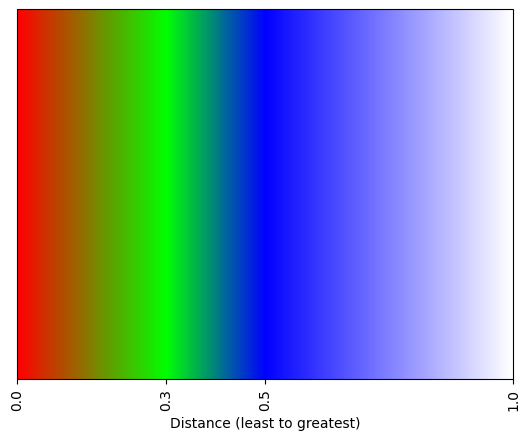

In [62]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def get_colormap(values, colors, name="custom"):
    values = np.sort(np.array(values))
    #values = np.interp(values, (values.min(), values.max()), (0., 1.))
    cmap = mpl.colors.LinearSegmentedColormap.from_list(name, list(zip(values, colors)))
    return cmap

distance_list = [0, 0.3, 0.5, 1]

min_val, max_val = min(distance_list), max(distance_list)

# use the coolwarm colormap that is built-in, and goes from blue to red
# Define your colors as RGB tuples
colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1), (1, 1, 1)] # Red -> Green -> Blue

# Create a smooth gradient colormap
cmap_name = 'smooth_gradient'
cmap = LinearSegmentedColormap.from_list(cmap_name, colors, )

cmap = get_colormap(distance_list, colors)

norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)

# convert your distances to color coordinates
color_list = cmap(distance_list)

fig, ax = plt.subplots()
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, ticks = sorted(distance_list), orientation='horizontal')
cb.set_label('Distance (least to greatest)')
ax.tick_params(axis='x', rotation=90)

plt.show()


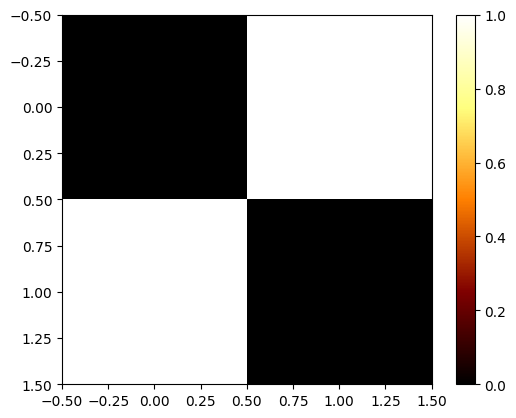

In [37]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the color dictionary
cdict = {'red':   [(0.0,  0.0, 0.0),
                   (0.5,  1.0, 1.0),
                   (1.0,  1.0, 1.0)],

         'green': [(0.0,  0.0, 0.0),
                   (0.25, 0.0, 0.0),
                   (0.75, 1.0, 1.0),
                   (1.0,  1.0, 1.0)],

         'blue': [(0.0,  0.0, 0.0),
                   (0.5,  0.0, 0.0),
                   (1.0,  1.0, 1.0)]}

# Create the colormap
cmap = LinearSegmentedColormap('my_smooth_cmap', cdict)

# Example usage of the colormap
fig, ax = plt.subplots()
im = ax.imshow([[0, 1], [1, 0]], cmap=cmap)
fig.colorbar(im)
plt.show()